# 🌿 CropGuard: A Data Mining Approach for Crop Disease Detection
### Full Project — EDA + Multiple Models + CNN Transfer Learning + Model Saving
---
**Datasets:**
- PlantVillage — `emmarex/plantdisease` (38 classes)
- New Plant Diseases Dataset — `vipoooool/new-plant-diseases-dataset` (38 classes, more images)

**Models:**
1. Decision Tree
2. Random Forest
3. SVM
4. CNN — MobileNetV2 Transfer Learning *(best accuracy)*

**Goal:** Compare all models → save best model → deploy on Streamlit

## ─────────────────────────────────
## PART 1 — SETUP & DATA LOADING
## ─────────────────────────────────

## Step 1 — Import All Libraries

In [1]:
import numpy as np
import pandas as pd
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from scipy.spatial.distance import euclidean
import kagglehub

# Sklearn — classical models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# TensorFlow / Keras — CNN
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

print('All libraries imported successfully!')
print(f'TensorFlow version: {tf.__version__}')

All libraries imported successfully!
TensorFlow version: 2.19.1


## Step 2 — Download Datasets

In [2]:
path1 = kagglehub.dataset_download('emmarex/plantdisease')
DATASET_PATH_1 = os.path.join(path1, 'PlantVillage')
print('Dataset 1 (PlantVillage):', DATASET_PATH_1)

path2 = kagglehub.dataset_download('vipoooool/new-plant-diseases-dataset')

DATASET_PATH_2_TRAIN = os.path.join(path2, 'New Plant Diseases Dataset(Augmented)', 'train')
DATASET_PATH_2_VALID = os.path.join(path2, 'New Plant Diseases Dataset(Augmented)', 'valid')

print('Dataset 2 (New Plant Diseases):', DATASET_PATH_2_TRAIN, 'and', DATASET_PATH_2_VALID)



Dataset 1 (PlantVillage): C:\Users\nadaa\.cache\kagglehub\datasets\emmarex\plantdisease\versions\1\PlantVillage
Dataset 2 (New Plant Diseases): C:\Users\nadaa\.cache\kagglehub\datasets\vipoooool\new-plant-diseases-dataset\versions\2\New Plant Diseases Dataset(Augmented)\train and C:\Users\nadaa\.cache\kagglehub\datasets\vipoooool\new-plant-diseases-dataset\versions\2\New Plant Diseases Dataset(Augmented)\valid


In [3]:
import os

path2 = kagglehub.dataset_download('vipoooool/new-plant-diseases-dataset')

# fix nested folder
base = os.path.join(
    path2,
    'New Plant Diseases Dataset(Augmented)',
    'New Plant Diseases Dataset(Augmented)'
)

DATASET_PATH_2_TRAIN = os.path.join(base, 'train')

# detect valid / val
if 'valid' in os.listdir(base):
    DATASET_PATH_2_VALID = os.path.join(base, 'valid')
else:
    DATASET_PATH_2_VALID = os.path.join(base, 'val')

print("Train:", DATASET_PATH_2_TRAIN)
print("Valid:", DATASET_PATH_2_VALID)
print("Train exists:", os.path.exists(DATASET_PATH_2_TRAIN))
print("Valid exists:", os.path.exists(DATASET_PATH_2_VALID))

Train: C:\Users\nadaa\.cache\kagglehub\datasets\vipoooool\new-plant-diseases-dataset\versions\2\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\train
Valid: C:\Users\nadaa\.cache\kagglehub\datasets\vipoooool\new-plant-diseases-dataset\versions\2\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\valid
Train exists: True
Valid exists: True


## ─────────────────────────────────
## PART 2 — EDA (Dataset 1)
## ─────────────────────────────────

## Step 3 — Load Images & Extract Features (Dataset 1)

In [4]:
rows = []
print('Loading images from Dataset 1...')

for class_folder in os.listdir(DATASET_PATH_1):
    class_path = os.path.join(DATASET_PATH_1, class_folder)
    if os.path.isdir(class_path):
        images = [f for f in os.listdir(class_path)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        for img_file in images:
            img_path = os.path.join(class_path, img_file)
            try:
                img = Image.open(img_path).convert('RGB')
                arr = np.array(img.resize((64, 64))).astype(float)
                rows.append({
                    'filename':   img_file,
                    'class':      class_folder,
                    'mean_R':     arr[:,:,0].mean(),
                    'mean_G':     arr[:,:,1].mean(),
                    'mean_B':     arr[:,:,2].mean(),
                    'std_R':      arr[:,:,0].std(),
                    'std_G':      arr[:,:,1].std(),
                    'std_B':      arr[:,:,2].std(),
                    'brightness': arr.mean(),
                })
            except Exception:
                pass

df = pd.DataFrame(rows)
print(f'Total images loaded : {len(df)}')
print(f'Total classes       : {df["class"].nunique()}')
df.head()

Loading images from Dataset 1...
Total images loaded : 20638
Total classes       : 15


,filename,class,mean_R,mean_G,mean_B,std_R,std_G,std_B,brightness
0,0022d6b7-d47c-4ee2-ae9a-392a53f48647___JR_B.Sp...,Pepper__bell___Bacterial_spot,124.468262,125.633789,108.484375,47.275037,37.722752,50.531852,119.528809
1,006adb74-934f-448f-a14f-62181742127b___JR_B.Sp...,Pepper__bell___Bacterial_spot,99.804443,106.239014,95.649414,47.852956,40.071844,51.767020,100.564290
2,00f2e69a-1e56-412d-8a79-fdce794a17e4___JR_B.Sp...,Pepper__bell___Bacterial_spot,128.867920,133.111816,125.541504,47.887144,38.783827,52.471860,129.173747
3,01613cd0-d3cd-4e96-945c-a312002037bf___JR_B.Sp...,Pepper__bell___Bacterial_spot,118.653076,129.784424,97.639160,41.599596,36.581054,48.372801,115.358887
4,0169b9ac-07b9-4be1-8b85-da94481f05a4___NREC_B....,Pepper__bell___Bacterial_spot,94.515625,103.369873,79.208252,54.417106,46.537558,55.417854,92.364583


## Step 4 — Basic Statistics & Missing Values

In [5]:
print('=== Dataset Shape ===')
print(df.shape)
print()
print('=== Basic Statistics ===')
display(df.describe())
print()
print('=== Missing Values ===')
print(df.isnull().sum())

# Fill missing values
df = df.fillna(df.median(numeric_only=True))
print('\nMissing values after fill:', df.isnull().sum().sum())

=== Dataset Shape ===
(20638, 9)

=== Basic Statistics ===


,mean_R,mean_G,mean_B,std_R,std_G,std_B,brightness
count,20638.000000,20638.000000,20638.000000,20638.000000,20638.000000,20638.000000,20638.000000
mean,116.994361,121.134644,104.884735,40.943094,34.580474,45.659256,114.337913
std,18.018919,17.275381,17.466697,10.814652,9.552950,10.066647,16.420246
min,8.347412,8.712158,5.743164,8.739276,7.350812,10.828948,7.694010
25%,106.778748,110.942871,94.240051,34.243266,27.648777,39.948046,104.947673
50%,117.506958,120.571899,105.888062,41.679664,33.955797,45.838607,114.422078
75%,127.262024,130.219971,115.845398,48.106838,40.785858,52.345473,123.443156
max,194.232178,201.574219,188.663574,92.583412,89.111749,84.591304,192.921224



=== Missing Values ===
filename      0
class         0
mean_R        0
mean_G        0
mean_B        0
std_R         0
std_G         0
std_B         0
brightness    0
dtype: int64

Missing values after fill: 0


## Step 5 — Class Distribution, Variance, Covariance, Euclidean Distance

=== Images Per Class ===
class
Tomato__Tomato_YellowLeaf__Curl_Virus          3208
Tomato_Bacterial_spot                          2127
Tomato_Late_blight                             1909
Tomato_Septoria_leaf_spot                      1771
Tomato_Spider_mites_Two_spotted_spider_mite    1676
Tomato_healthy                                 1591
Pepper__bell___healthy                         1478
Tomato__Target_Spot                            1404
Potato___Early_blight                          1000
Potato___Late_blight                           1000
Tomato_Early_blight                            1000
Pepper__bell___Bacterial_spot                   997
Tomato_Leaf_Mold                                952
Tomato__Tomato_mosaic_virus                     373
Potato___healthy                                152
Name: count, dtype: int64


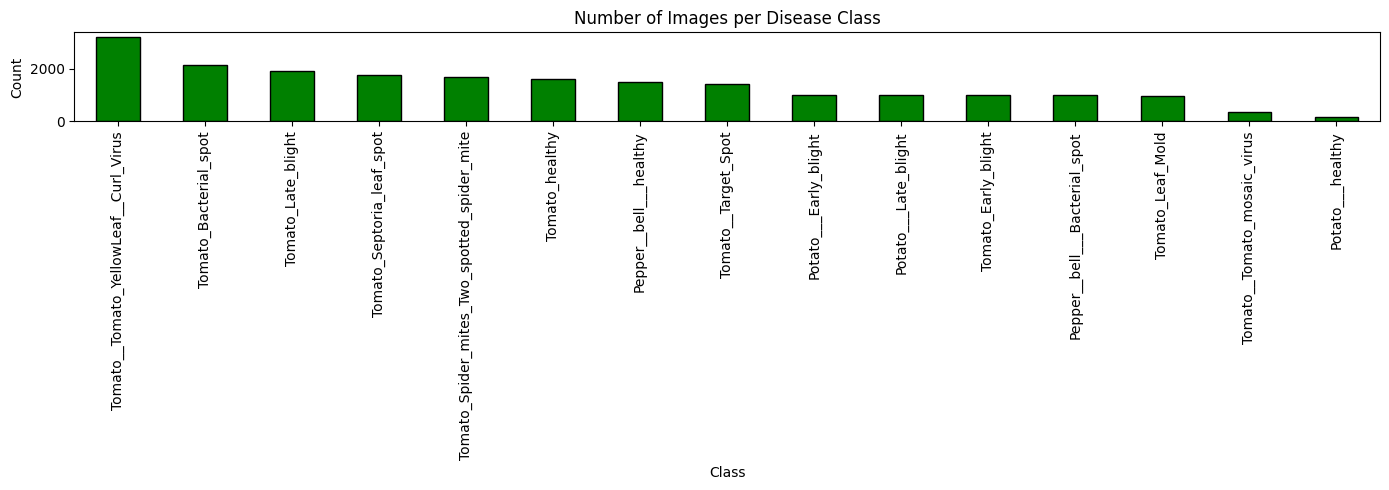


=== Variance ===
mean_R        324.681435
mean_G        298.438794
mean_B        305.085504
brightness    269.624484
dtype: float64

=== Covariance Matrix ===
                mean_R      mean_G      mean_B  brightness
mean_R      324.681435  283.719252  242.772534  283.724407
mean_G      283.719252  298.438794  222.715524  268.291190
mean_B      242.772534  222.715524  305.085504  256.857854
brightness  283.724407  268.291190  256.857854  269.624484

=== Euclidean Distance (img1 vs img2) ===
38.8439

=== Brightness Stats ===
Mean=114.34  Std=16.42  Min=7.69  Max=192.92
NaN count: 0


In [6]:
# Class distribution
class_counts = df['class'].value_counts()
print('=== Images Per Class ===')
print(class_counts)

plt.figure(figsize=(14, 5))
class_counts.plot(kind='bar', color='green', edgecolor='black')
plt.title('Number of Images per Disease Class')
plt.xlabel('Class'); plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120)
plt.show()

# Variance
print('\n=== Variance ===')
print(df[['mean_R','mean_G','mean_B','brightness']].var())

# Covariance
print('\n=== Covariance Matrix ===')
print(df[['mean_R','mean_G','mean_B','brightness']].cov())

# Euclidean Distance
r1 = df[['mean_R','mean_G','mean_B','brightness']].iloc[0].values
r2 = df[['mean_R','mean_G','mean_B','brightness']].iloc[1].values
print(f'\n=== Euclidean Distance (img1 vs img2) ===')
print(f'{euclidean(r1, r2):.4f}')

# NumPy stats on brightness
b = np.array(df['brightness'])
print(f'\n=== Brightness Stats ===')
print(f'Mean={np.mean(b):.2f}  Std={np.std(b):.2f}  Min={np.min(b):.2f}  Max={np.max(b):.2f}')
print(f'NaN count: {np.isnan(b).sum()}')

## ─────────────────────────────────
## PART 3 — CLASSICAL MODELS (DT, RF, SVM)
## ─────────────────────────────────

## Step 6 — Prepare Features & Labels

In [7]:
feature_cols = ['mean_R','mean_G','mean_B','std_R','std_G','std_B','brightness']
X = df[feature_cols].values

le = LabelEncoder()
y = le.fit_transform(df['class'])

# Save label encoder for Streamlit
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f'Features : {feature_cols}')
print(f'Classes  : {len(le.classes_)}')
print(f'Train    : {X_train.shape[0]} samples')
print(f'Test     : {X_test.shape[0]} samples')

Features : ['mean_R', 'mean_G', 'mean_B', 'std_R', 'std_G', 'std_B', 'brightness']
Classes  : 15
Train    : 14446 samples
Test     : 6192 samples


## Step 7 — Model 1: Decision Tree

In [8]:
print('Training Decision Tree...')
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train, y_train)

dt_train_acc = accuracy_score(y_train, dt.predict(X_train))
dt_test_acc  = accuracy_score(y_test,  dt.predict(X_test))

print(f'Decision Tree — Train: {dt_train_acc*100:.2f}%  |  Test: {dt_test_acc*100:.2f}%')

# Feature importance
feat_df = pd.DataFrame({'Feature': feature_cols, 'Importance': dt.feature_importances_})
feat_df = feat_df.sort_values('Importance', ascending=False)
print(feat_df.to_string(index=False))

Training Decision Tree...
Decision Tree — Train: 63.50%  |  Test: 52.36%
   Feature  Importance
    mean_B    0.173852
     std_B    0.168024
    mean_G    0.167236
     std_R    0.160337
     std_G    0.158904
    mean_R    0.156236
brightness    0.015410


## Step 8 — Model 2: Random Forest

In [9]:
print('Training Random Forest...')
rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_train_acc = accuracy_score(y_train, rf.predict(X_train))
rf_test_acc  = accuracy_score(y_test,  rf.predict(X_test))

print(f'Random Forest — Train: {rf_train_acc*100:.2f}%  |  Test: {rf_test_acc*100:.2f}%')

# Save Random Forest model
with open('rf_model.pkl', 'wb') as f:
    pickle.dump(rf, f)
print('Random Forest model saved as rf_model.pkl')

Training Random Forest...
Random Forest — Train: 96.24%  |  Test: 66.25%
Random Forest model saved as rf_model.pkl


## Step 9 — Model 3: SVM

In [10]:
print('Training SVM... (this may take a few minutes)')
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm.fit(X_train, y_train)

svm_train_acc = accuracy_score(y_train, svm.predict(X_train))
svm_test_acc  = accuracy_score(y_test,  svm.predict(X_test))

print(f'SVM — Train: {svm_train_acc*100:.2f}%  |  Test: {svm_test_acc*100:.2f}%')

Training SVM... (this may take a few minutes)
SVM — Train: 63.80%  |  Test: 63.84%


## Step 10 — Compare Classical Models

=== Classical Models Comparison ===
        Model  Train Accuracy  Test Accuracy
Decision Tree       63.498546      52.357881
Random Forest       96.241174      66.246770
          SVM       63.796207      63.840439


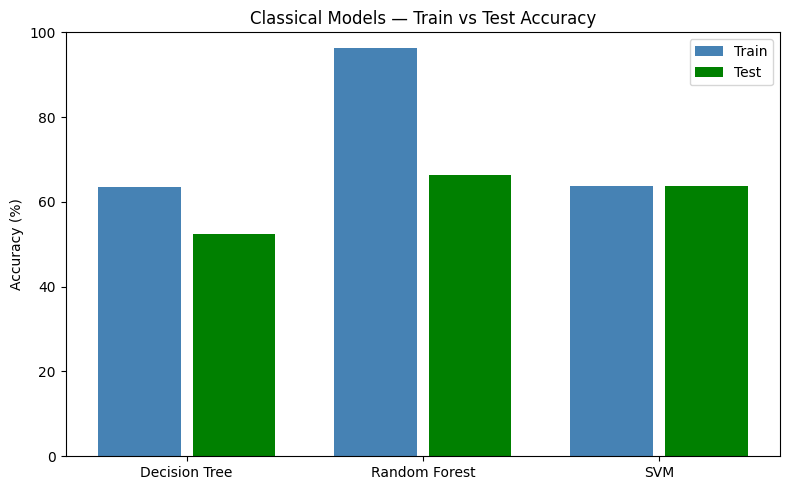

In [11]:
results_classical = pd.DataFrame({
    'Model':          ['Decision Tree', 'Random Forest', 'SVM'],
    'Train Accuracy': [dt_train_acc*100, rf_train_acc*100, svm_train_acc*100],
    'Test Accuracy':  [dt_test_acc*100,  rf_test_acc*100,  svm_test_acc*100],
})

print('=== Classical Models Comparison ===')
print(results_classical.to_string(index=False))

x = np.arange(3)
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - 0.2, results_classical['Train Accuracy'], 0.35, label='Train', color='steelblue')
ax.bar(x + 0.2, results_classical['Test Accuracy'],  0.35, label='Test',  color='green')
ax.set_xticks(x)
ax.set_xticklabels(results_classical['Model'])
ax.set_ylabel('Accuracy (%)')
ax.set_title('Classical Models — Train vs Test Accuracy')
ax.legend()
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig('classical_models_comparison.png', dpi=120)
plt.show()

## ─────────────────────────────────
## PART 4 — CNN (MobileNetV2 Transfer Learning)
## ─────────────────────────────────

## Step 11 — Prepare CNN Data Generators (Dataset 2)
Dataset 2 already has `train/` and `valid/` folders — perfect for CNN training.

In [12]:
print(os.listdir(path2))

['New Plant Diseases Dataset(Augmented)', 'test']


In [13]:
print("Train exists:", os.path.exists(DATASET_PATH_2_TRAIN))
print("Valid exists:", os.path.exists(DATASET_PATH_2_VALID))
print(DATASET_PATH_2_TRAIN)
print(DATASET_PATH_2_VALID)

Train exists: True
Valid exists: True
C:\Users\nadaa\.cache\kagglehub\datasets\vipoooool\new-plant-diseases-dataset\versions\2\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\train
C:\Users\nadaa\.cache\kagglehub\datasets\vipoooool\new-plant-diseases-dataset\versions\2\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\valid


In [14]:
base = r"C:\Users\nadaa\.cache\kagglehub\datasets\vipoooool\new-plant-diseases-dataset\versions\2\New Plant Diseases Dataset(Augmented)"
import os
print(os.listdir(base))

['New Plant Diseases Dataset(Augmented)']


In [15]:
import os

base = r"C:\Users\nadaa\.cache\kagglehub\datasets\vipoooool\new-plant-diseases-dataset\versions\2"

for root, dirs, files in os.walk(base):
    if "train" in dirs:
        print("TRAIN FOUND AT:", os.path.join(root, "train"))

TRAIN FOUND AT: C:\Users\nadaa\.cache\kagglehub\datasets\vipoooool\new-plant-diseases-dataset\versions\2\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\train


In [16]:
DATASET_PATH_2_TRAIN = r"C:\Users\nadaa\.cache\kagglehub\datasets\vipoooool\new-plant-diseases-dataset\versions\2\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\train"

DATASET_PATH_2_VALID = r"C:\Users\nadaa\.cache\kagglehub\datasets\vipoooool\new-plant-diseases-dataset\versions\2\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\valid"

In [17]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

# Training generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
)

# Validation generator — no augmentation
valid_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    DATASET_PATH_2_TRAIN,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

valid_gen = valid_datagen.flow_from_directory(
    DATASET_PATH_2_VALID,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

NUM_CLASSES = len(train_gen.class_indices)
print(f'Number of classes : {NUM_CLASSES}')
print(f'Training samples  : {train_gen.samples}')
print(f'Validation samples: {valid_gen.samples}')

# Save class indices for Streamlit
import json
class_indices = {v: k for k, v in train_gen.class_indices.items()}
with open('class_indices.json', 'w') as f:
    json.dump(class_indices, f)
print('Class indices saved as class_indices.json')

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.
Number of classes : 38
Training samples  : 70295
Validation samples: 17572
Class indices saved as class_indices.json


## Step 12 — Build MobileNetV2 Model
We use Transfer Learning — MobileNetV2 pretrained on ImageNet, add our own classification head.

In [18]:
# Load MobileNetV2 base — no top layer
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model layers
base_model.trainable = False

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

cnn_model = Model(inputs=base_model.input, outputs=output)

cnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Model summary:')
cnn_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Model summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,595,686 (9.90 MB)

 Trainable params: 337,702 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Step 13 — Train CNN Model

In [19]:
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True),
    ModelCheckpoint('cnn_best_model.h5', monitor='val_accuracy', save_best_only=True)
]

print('Training CNN (Phase 1 — frozen base)...')
history = cnn_model.fit(
    train_gen,
    epochs=10,
    validation_data=valid_gen,
    callbacks=callbacks
)
print('Phase 1 training complete!')

Training CNN (Phase 1 — frozen base)...
Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7087 - loss: 1.0019

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2649s 1s/step - accuracy: 0.8089 - loss: 0.6164 - val_accuracy: 0.9103 - val_loss: 0.2722
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 826ms/step - accuracy: 0.8825 - loss: 0.3593

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2179s 992ms/step - accuracy: 0.8843 - loss: 0.3537 - val_accuracy: 0.9196 - val_loss: 0.2341
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 807ms/step - accuracy: 0.8947 - loss: 0.3189

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2144s 976ms/step - accuracy: 0.8944 - loss: 0.3173 - val_accuracy: 0.9310 - val_loss: 0.2046
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 743ms/step - accuracy: 0.9030 - loss: 0.2893

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1959s 892ms/step - accuracy: 0.9021 - loss: 0.2912 - val_accuracy: 0.9335 - val_loss: 0.1948
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1868s 850ms/step - accuracy: 0.9076 - loss: 0.2774 - val_accuracy: 0.9313 - val_loss: 0.2066
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 769ms/step - accuracy: 0.9138 - loss: 0.2583

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2049s 933ms/step - accuracy: 0.9134 - loss: 0.2611 - val_accuracy: 0.9368 - val_loss: 0.1862
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1959s 892ms/step - accuracy: 0.9141 - loss: 0.2583 - val_accuracy: 0.9338 - val_loss: 0.2046
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 962ms/step - accuracy: 0.9190 - loss: 0.2410

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2473s 1s/step - accuracy: 0.9162 - loss: 0.2491 - val_accuracy: 0.9369 - val_loss: 0.1895
Epoch 9/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 839ms/step - accuracy: 0.9190 - loss: 0.2457

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2270s 1s/step - accuracy: 0.9186 - loss: 0.2457 - val_accuracy: 0.9456 - val_loss: 0.1649
Epoch 10/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2404s 1s/step - accuracy: 0.9191 - loss: 0.2434 - val_accuracy: 0.9363 - val_loss: 0.1915
Phase 1 training complete!


## Step 14 — Fine-Tune CNN (Unfreeze last 30 layers)

In [20]:
# Unfreeze last 30 layers
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

cnn_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Training CNN (Phase 2 — fine-tuning)...')
history_ft = cnn_model.fit(
    train_gen,
    epochs=10,
    validation_data=valid_gen,
    callbacks=callbacks
)
print('Fine-tuning complete!')

# Save final model
cnn_model.save('cnn_best_model.h5')
print('CNN model saved as cnn_best_model.h5')

Training CNN (Phase 2 — fine-tuning)...
Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2723s 1s/step - accuracy: 0.8483 - loss: 0.5634 - val_accuracy: 0.9356 - val_loss: 0.2021
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 850ms/step - accuracy: 0.9080 - loss: 0.2804

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2142s 975ms/step - accuracy: 0.9133 - loss: 0.2622 - val_accuracy: 0.9460 - val_loss: 0.1625
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 703ms/step - accuracy: 0.9290 - loss: 0.2112

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1818s 828ms/step - accuracy: 0.9315 - loss: 0.2057 - val_accuracy: 0.9555 - val_loss: 0.1375
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 703ms/step - accuracy: 0.9406 - loss: 0.1779

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1820s 828ms/step - accuracy: 0.9410 - loss: 0.1755 - val_accuracy: 0.9623 - val_loss: 0.1179
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 903ms/step - accuracy: 0.9487 - loss: 0.1567

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2343s 1s/step - accuracy: 0.9488 - loss: 0.1528 - val_accuracy: 0.9654 - val_loss: 0.1082
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 936ms/step - accuracy: 0.9549 - loss: 0.1364

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2416s 1s/step - accuracy: 0.9544 - loss: 0.1348 - val_accuracy: 0.9663 - val_loss: 0.1038
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 920ms/step - accuracy: 0.9570 - loss: 0.1280

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2373s 1s/step - accuracy: 0.9581 - loss: 0.1244 - val_accuracy: 0.9680 - val_loss: 0.1004
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 955ms/step - accuracy: 0.9615 - loss: 0.1096

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2470s 1s/step - accuracy: 0.9606 - loss: 0.1134 - val_accuracy: 0.9710 - val_loss: 0.0899
Epoch 9/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2542s 1s/step - accuracy: 0.9652 - loss: 0.1024 - val_accuracy: 0.9701 - val_loss: 0.0949
Epoch 10/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.9669 - loss: 0.0966

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 21688s 10s/step - accuracy: 0.9670 - loss: 0.0967 - val_accuracy: 0.9716 - val_loss: 0.0872


Fine-tuning complete!
CNN model saved as cnn_best_model.h5


## Step 15 — Evaluate CNN

550/550 ━━━━━━━━━━━━━━━━━━━━ 363s 659ms/step - accuracy: 0.9716 - loss: 0.0872
CNN Validation Accuracy: 97.16%


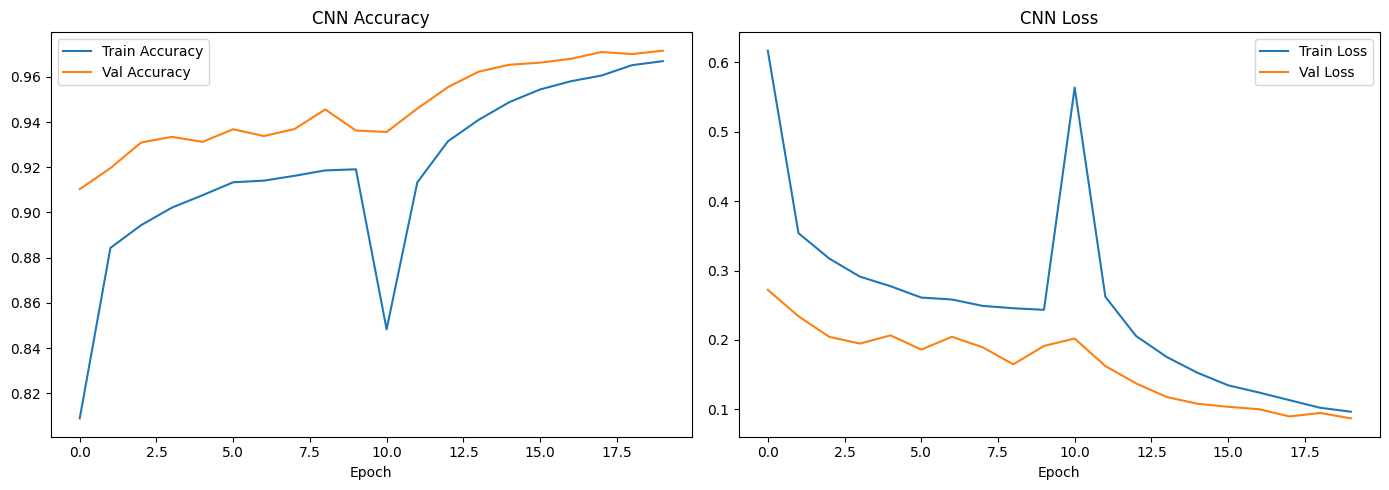

In [21]:
cnn_loss, cnn_acc = cnn_model.evaluate(valid_gen)
print(f'CNN Validation Accuracy: {cnn_acc*100:.2f}%')

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Combine phase 1 + phase 2
all_acc     = history.history['accuracy']     + history_ft.history['accuracy']
all_val_acc = history.history['val_accuracy'] + history_ft.history['val_accuracy']
all_loss    = history.history['loss']         + history_ft.history['loss']
all_val_loss= history.history['val_loss']     + history_ft.history['val_loss']

axes[0].plot(all_acc,     label='Train Accuracy')
axes[0].plot(all_val_acc, label='Val Accuracy')
axes[0].set_title('CNN Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(all_loss,     label='Train Loss')
axes[1].plot(all_val_loss, label='Val Loss')
axes[1].set_title('CNN Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('cnn_training_history.png', dpi=120)
plt.show()

## ─────────────────────────────────
## PART 5 — FINAL COMPARISON
## ─────────────────────────────────

## Step 16 — Compare ALL Models

=== ALL MODELS COMPARISON ===
            Model  Test Accuracy %                          Notes
CNN (MobileNetV2)        97.160256 Full image — Transfer Learning
    Random Forest        66.246770      Color features — ensemble
              SVM        63.840439    Color features — RBF kernel
    Decision Tree        52.357881            Color features only


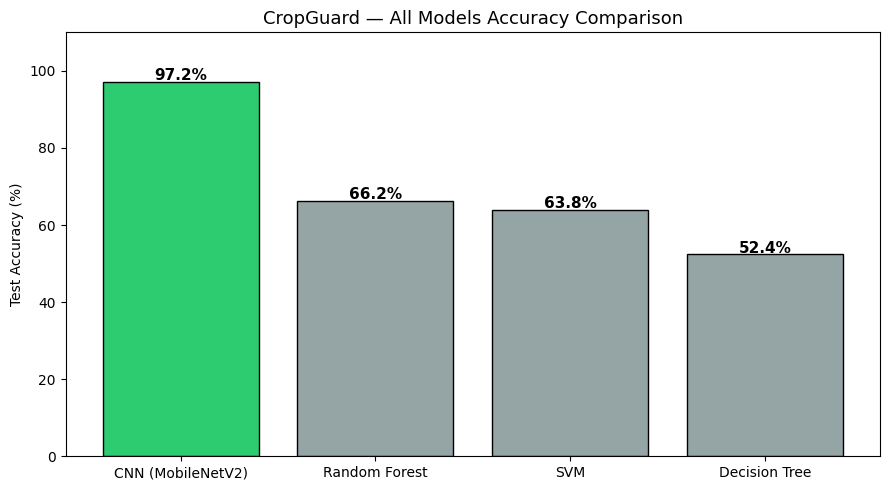


✅ Best model: CNN (MobileNetV2) — saved as cnn_best_model.h5


In [22]:
all_results = pd.DataFrame({
    'Model':           ['Decision Tree', 'Random Forest', 'SVM', 'CNN (MobileNetV2)'],
    'Test Accuracy %': [dt_test_acc*100,  rf_test_acc*100,  svm_test_acc*100, cnn_acc*100],
    'Notes':           [
        'Color features only',
        'Color features — ensemble',
        'Color features — RBF kernel',
        'Full image — Transfer Learning'
    ]
}).sort_values('Test Accuracy %', ascending=False)

print('=== ALL MODELS COMPARISON ===')
print(all_results.to_string(index=False))

# Bar chart
colors = ['#2ecc71' if acc == all_results['Test Accuracy %'].max() else '#95a5a6'
          for acc in all_results['Test Accuracy %']]

plt.figure(figsize=(9, 5))
bars = plt.bar(all_results['Model'], all_results['Test Accuracy %'], color=colors, edgecolor='black')
for bar, acc in zip(bars, all_results['Test Accuracy %']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.1f}%', ha='center', fontsize=11, fontweight='bold')
plt.title('CropGuard — All Models Accuracy Comparison', fontsize=13)
plt.ylabel('Test Accuracy (%)')
plt.ylim(0, 110)
plt.tight_layout()
plt.savefig('all_models_comparison.png', dpi=120)
plt.show()
print('\n✅ Best model: CNN (MobileNetV2) — saved as cnn_best_model.h5')

## Step 17 — Confusion Matrix (Best Classical: Random Forest)

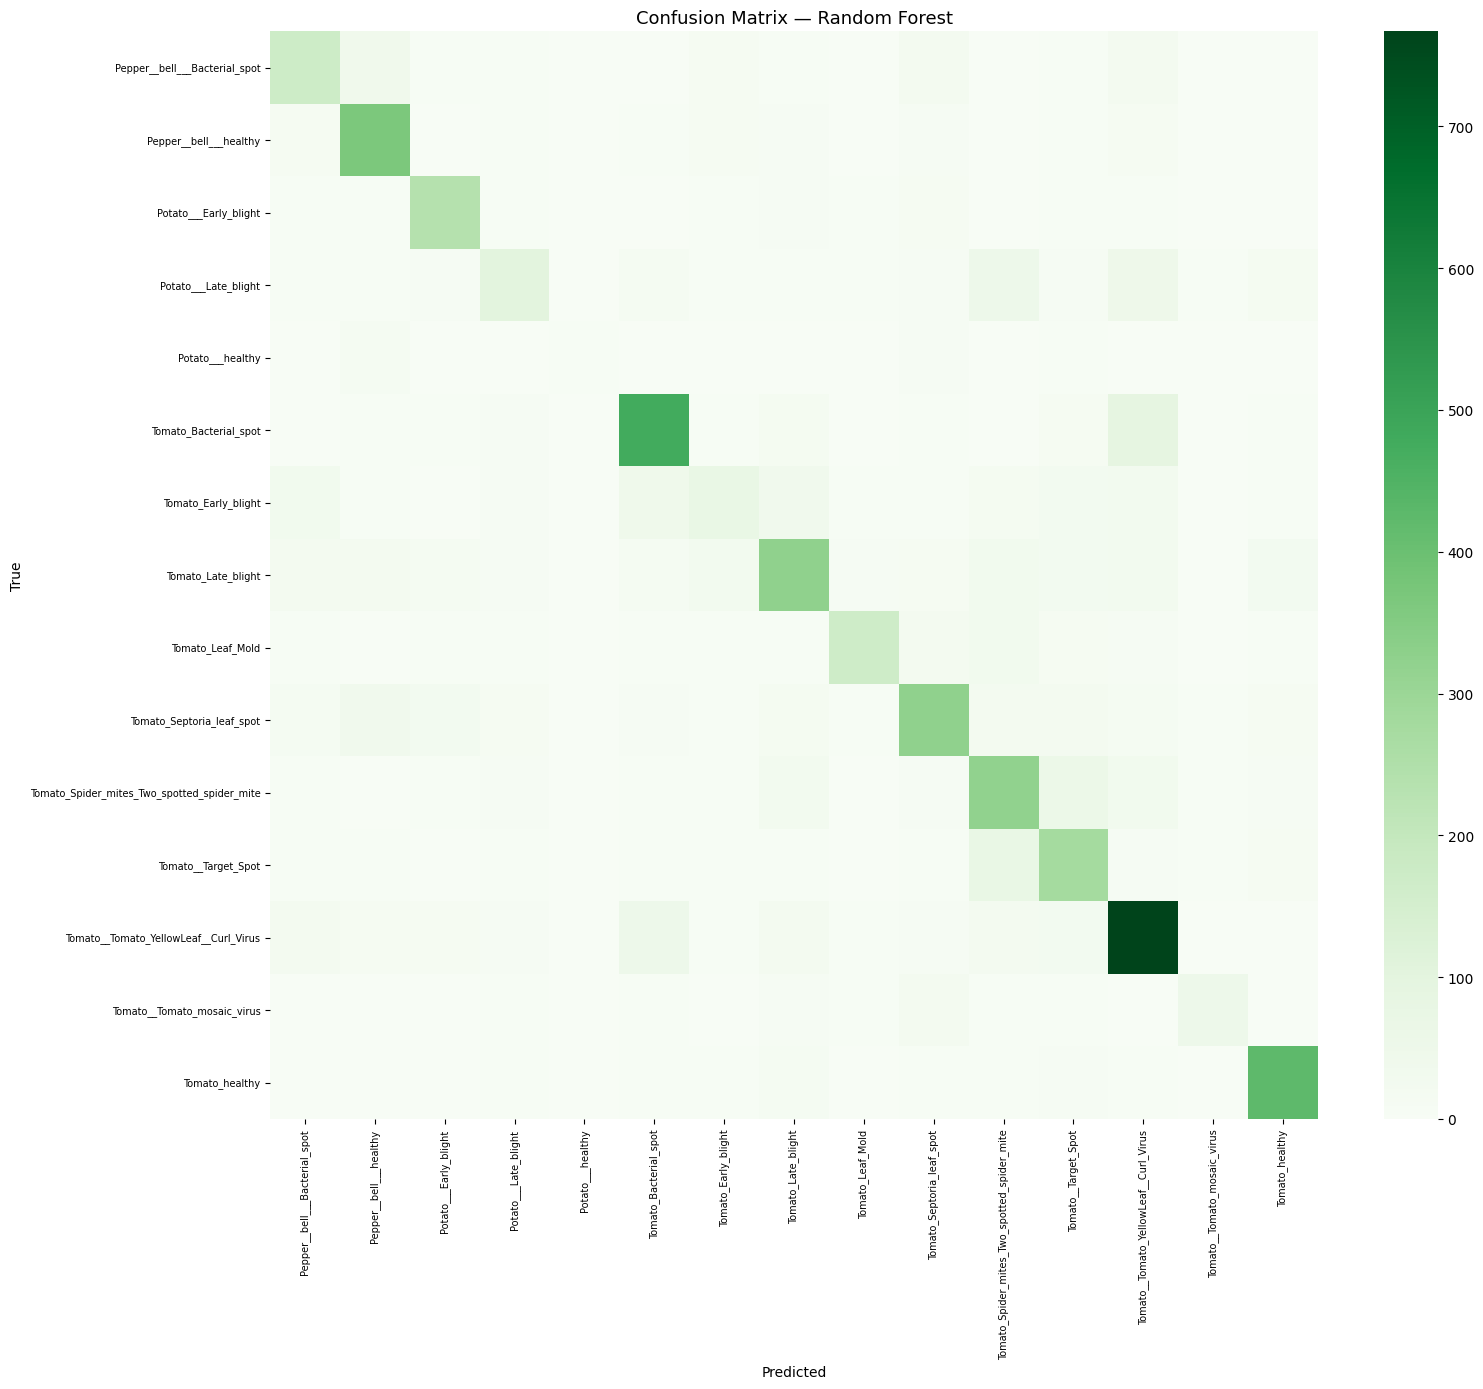


=== Classification Report — Random Forest ===
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.56      0.57      0.57       299
                     Pepper__bell___healthy       0.70      0.83      0.76       443
                      Potato___Early_blight       0.74      0.79      0.76       300
                       Potato___Late_blight       0.53      0.34      0.42       300
                           Potato___healthy       0.62      0.11      0.19        46
                      Tomato_Bacterial_spot       0.73      0.75      0.74       638
                        Tomato_Early_blight       0.42      0.25      0.31       300
                         Tomato_Late_blight       0.62      0.57      0.60       573
                           Tomato_Leaf_Mold       0.81      0.59      0.69       286
                  Tomato_Septoria_leaf_spot       0.66      0.61      0.64       531
Tomato_Spider_mit

In [23]:
y_pred_rf = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=False, cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix — Random Forest', fontsize=13)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig('confusion_matrix_RF.png', dpi=120)
plt.show()

print('\n=== Classification Report — Random Forest ===')
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

## Step 18 — Project Summary

In [24]:
print('=' * 60)
print('          🌿 CROPGUARD — PROJECT SUMMARY')
print('=' * 60)
print(f'  Dataset 1 (EDA + Classical) : PlantVillage')
print(f'  Dataset 2 (CNN Training)    : New Plant Diseases Dataset')
print(f'  Total Images (Dataset 1)    : {len(df)}')
print(f'  Number of Classes           : {len(le.classes_)}')
print('-' * 60)
print(f'  Decision Tree Accuracy      : {dt_test_acc*100:.2f}%')
print(f'  Random Forest Accuracy      : {rf_test_acc*100:.2f}%')
print(f'  SVM Accuracy                : {svm_test_acc*100:.2f}%')
print(f'  CNN (MobileNetV2) Accuracy  : {cnn_acc*100:.2f}%  ← BEST')
print('-' * 60)
print('  Saved Files:')
print('    cnn_best_model.h5    → CNN model for Streamlit')
print('    rf_model.pkl         → Random Forest model')
print('    label_encoder.pkl    → Label encoder')
print('    class_indices.json   → Class names for CNN')
print('=' * 60)

          🌿 CROPGUARD — PROJECT SUMMARY
  Dataset 1 (EDA + Classical) : PlantVillage
  Dataset 2 (CNN Training)    : New Plant Diseases Dataset
  Total Images (Dataset 1)    : 20638
  Number of Classes           : 15
------------------------------------------------------------
  Decision Tree Accuracy      : 52.36%
  Random Forest Accuracy      : 66.25%
  SVM Accuracy                : 63.84%
  CNN (MobileNetV2) Accuracy  : 97.16%  ← BEST
------------------------------------------------------------
  Saved Files:
    cnn_best_model.h5    → CNN model for Streamlit
    rf_model.pkl         → Random Forest model
    label_encoder.pkl    → Label encoder
    class_indices.json   → Class names for CNN
